In [ ]:
"""
ACCIDENT SEVERITY PREDICTION PROJECT
Notebook 3: Model Evaluation & Actionable Insights

First Quadrant Labs - Afeef Anver sha
Project Goal: Deep dive into model performance and extract actionable insights
"""

In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 2")

In [3]:
# IMPORT LIBRARIES

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

In [5]:
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_recall_curve, f1_score, 
                             precision_score, recall_score)

# Visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [6]:
# LOAD SAVED MODEL AND ARTIFACTS

In [7]:
# Check if models directory exists
if os.path.exists('models/'):
    model_dir = 'models/'
    print(" Found models/ directory")
else:
    model_dir = ''
    print(" Using current directory for model files")

 Found models/ directory


In [8]:
# Load model
try:
    with open(f'{model_dir}final_model.pkl', 'rb') as f:
        final_model = pickle.load(f)
    print(f" Loaded: {model_dir}final_model.pkl")
except FileNotFoundError:
    print(" Error: final_model.pkl not found. Run Notebook 2 first!")
    raise

 Loaded: models/final_model.pkl


In [9]:
# Load scaler
with open(f'{model_dir}scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
print(f" Loaded: {model_dir}scaler.pkl")

 Loaded: models/scaler.pkl


In [10]:
# Load label encoders
with open(f'{model_dir}label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)
print(f" Loaded: {model_dir}label_encoders.pkl")

 Loaded: models/label_encoders.pkl


In [11]:
# Load feature columns
with open(f'{model_dir}feature_columns.pkl', 'rb') as f:
    feature_cols = pickle.load(f)
print(f" Loaded: {model_dir}feature_columns.pkl")

 Loaded: models/feature_columns.pkl


In [12]:
# Load performance summary (optional)
try:
    with open(f'{model_dir}performance_summary.pkl', 'rb') as f:
        performance_summary = pickle.load(f)
    print(f" Loaded: {model_dir}performance_summary.pkl")
    best_model_name = performance_summary['Model']
except FileNotFoundError:
    best_model_name = type(final_model).__name__
    print(f" Performance summary not found, using model type: {best_model_name}")

 Loaded: models/performance_summary.pkl


In [13]:
# Load test predictions
predictions_df = pd.read_csv('test_predictions.csv')
print(" Loaded: test_predictions.csv")

 Loaded: test_predictions.csv


In [14]:
# Load model comparison results
comparison_df = pd.read_csv('model_comparison_results.csv')
print(" Loaded: model_comparison_results.csv")

 Loaded: model_comparison_results.csv


In [15]:
print(f"\nModel type: {type(final_model).__name__}")
print(f"Number of features: {len(feature_cols)}")
print(f"Test set size: {len(predictions_df):,}")


Model type: GradientBoostingClassifier
Number of features: 43
Test set size: 46,132


In [16]:
# MODEL PERFORMANCE METRICS

In [17]:
y_test = predictions_df['Actual']
y_pred = predictions_df['Predicted']
y_pred_proba = predictions_df['Predicted_Probability']

In [18]:
# Calculate all metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [19]:
# Confusion matrix components
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

In [20]:
print("\n PERFORMANCE METRICS:")
print(f"{'-'*50}")
print(f"Accuracy:          {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision:         {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:            {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:          {f1:.4f}")
print(f"ROC-AUC:           {roc_auc:.4f}")
print(f"Specificity:       {specificity:.4f} ({specificity*100:.2f}%)")
print(f"{'-'*50}")


 PERFORMANCE METRICS:
--------------------------------------------------
Accuracy:          0.9966 (99.66%)
Precision:         0.7674 (76.74%)
Recall:            0.3220 (32.20%)
F1-Score:          0.4536
ROC-AUC:           0.8975
Specificity:       0.9996 (99.96%)
--------------------------------------------------


In [21]:
print("\n CONFUSION MATRIX BREAKDOWN:")
print(f"True Negatives:    {tn:,} (correctly predicted injured)")
print(f"False Positives:   {fp:,} (predicted fatal, actually injured)")
print(f"False Negatives:   {fn:,} (predicted injured, actually fatal) ")
print(f"True Positives:    {tp:,} (correctly predicted fatal)")


 CONFUSION MATRIX BREAKDOWN:
True Negatives:    45,907 (correctly predicted injured)
False Positives:   20 (predicted fatal, actually injured)
False Negatives:   139 (predicted injured, actually fatal) 
True Positives:    66 (correctly predicted fatal)


In [22]:
print("\n ERROR ANALYSIS:")
print(f"False Positive Rate: {false_positive_rate:.4f} ({false_positive_rate*100:.2f}%)")
print(f"False Negative Rate: {false_negative_rate:.4f} ({false_negative_rate*100:.2f}%)")


 ERROR ANALYSIS:
False Positive Rate: 0.0004 (0.04%)
False Negative Rate: 0.6780 (67.80%)


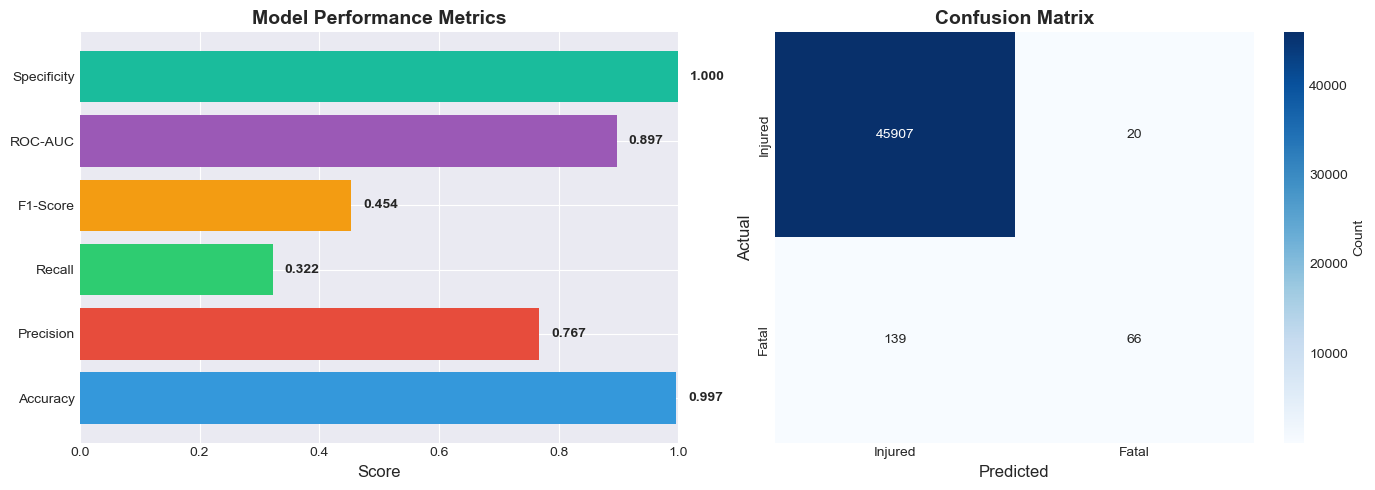

In [23]:
# Metrics visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of metrics
metrics_dict = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'ROC-AUC': roc_auc,
    'Specificity': specificity
}

axes[0].barh(list(metrics_dict.keys()), list(metrics_dict.values()), 
             color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c'])
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('Score', fontsize=12)
axes[0].set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
for i, (metric, value) in enumerate(metrics_dict.items()):
    axes[0].text(value + 0.02, i, f'{value:.3f}', va='center', fontweight='bold')

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Injured', 'Fatal'],
            yticklabels=['Injured', 'Fatal'],
            cbar_kws={'label': 'Count'})
axes[1].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.show()

In [24]:
# ROC CURVE ANALYSIS

In [25]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Find optimal threshold (Youden's J statistic)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"\nROC-AUC Score: {roc_auc:.4f}")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"  At this threshold:")
print(f"    True Positive Rate: {tpr[optimal_idx]:.4f}")
print(f"    False Positive Rate: {fpr[optimal_idx]:.4f}")


ROC-AUC Score: 0.8975
Optimal Threshold: 0.0041
  At this threshold:
    True Positive Rate: 0.8634
    False Positive Rate: 0.2571


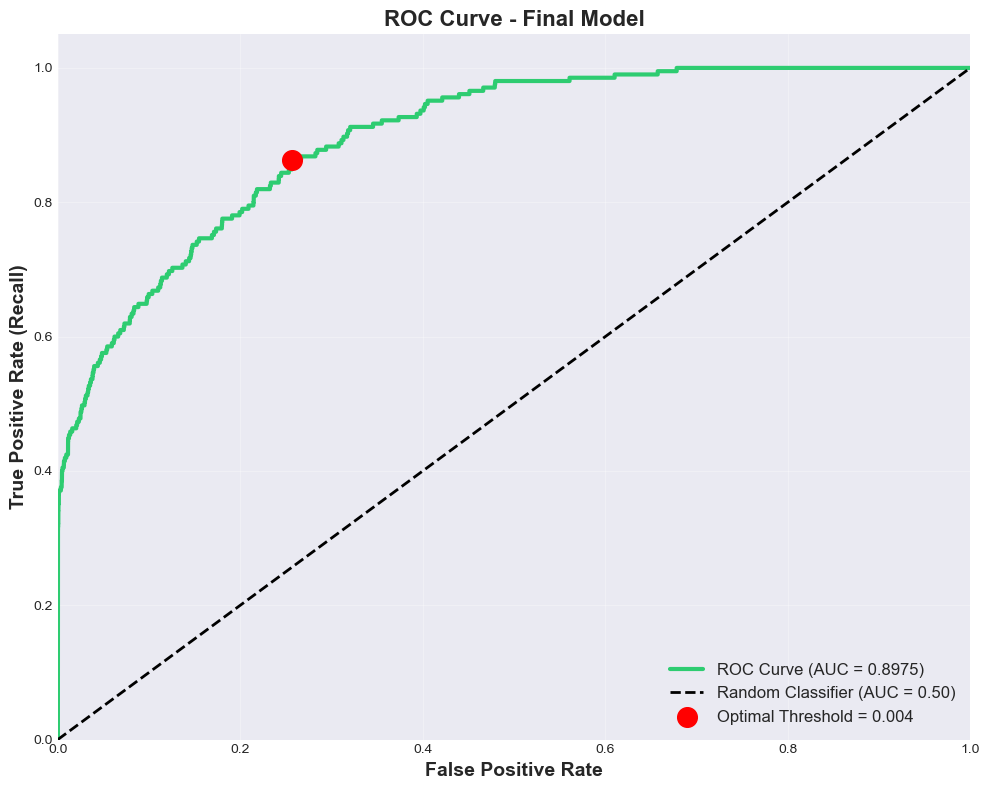

In [26]:
# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, linewidth=3, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='#2ecc71')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.50)')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', s=200, 
            label=f'Optimal Threshold = {optimal_threshold:.3f}', zorder=3)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate (Recall)', fontsize=14, fontweight='bold')
plt.title('ROC Curve - Final Model', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# PRECISION-RECALL CURVE

In [27]:
# Calculate PR curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)

# Find F1-optimal threshold
f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-10)
f1_optimal_idx = np.argmax(f1_scores)
f1_optimal_threshold = pr_thresholds[f1_optimal_idx]

In [28]:
print(f"\nF1-Optimal Threshold: {f1_optimal_threshold:.4f}")
print(f"  At this threshold:")
print(f"    Precision: {precision_curve[f1_optimal_idx]:.4f}")
print(f"    Recall: {recall_curve[f1_optimal_idx]:.4f}")
print(f"    F1-Score: {f1_scores[f1_optimal_idx]:.4f}")


F1-Optimal Threshold: 0.3873
  At this threshold:
    Precision: 0.6893
    Recall: 0.3463
    F1-Score: 0.4610


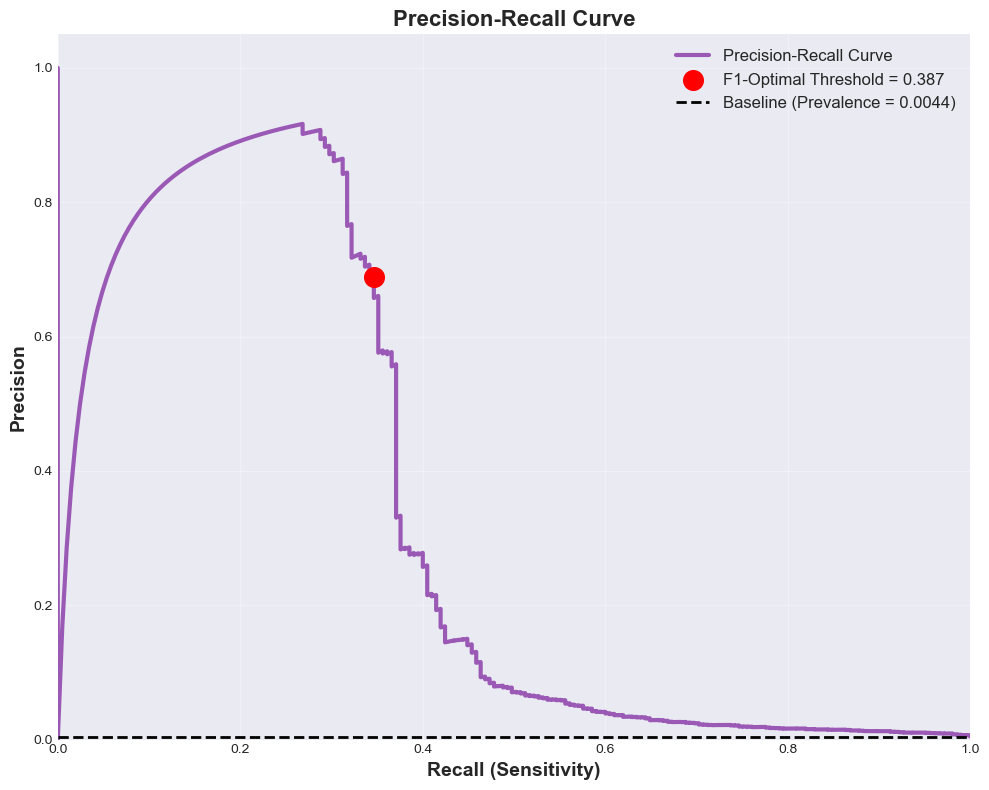

In [29]:
# Plot PR curve
plt.figure(figsize=(10, 8))
plt.plot(recall_curve, precision_curve, linewidth=3, color='#9b59b6', label='Precision-Recall Curve')
plt.scatter(recall_curve[f1_optimal_idx], precision_curve[f1_optimal_idx], 
            marker='o', color='red', s=200, label=f'F1-Optimal Threshold = {f1_optimal_threshold:.3f}', zorder=3)

# Baseline (prevalence)
baseline_precision = y_test.mean()
plt.axhline(y=baseline_precision, color='k', linestyle='--', linewidth=2, 
            label=f'Baseline (Prevalence = {baseline_precision:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Sensitivity)', fontsize=14, fontweight='bold')
plt.ylabel('Precision', fontsize=14, fontweight='bold')
plt.title('Precision-Recall Curve', fontsize=16, fontweight='bold')
plt.legend(loc='best', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# FEATURE IMPORTANCE ANALYSIS


Top 20 Most Important Features:
--------------------------------------------------
                 Feature  Importance
       COMPLAINT_encoded    0.248125
EMOTIONAL_STATUS_encoded    0.198823
              CRASH_YEAR    0.159946
           IS_PEDESTRIAN    0.083595
       CRASH_DAY_OF_WEEK    0.054727
             CRASH_MONTH    0.051479
       AGE_GROUP_encoded    0.042600
              PERSON_AGE    0.035124
                IS_NIGHT    0.030025
              CRASH_HOUR    0.026332
   BODILY_INJURY_encoded    0.022838
            IS_RUSH_HOUR    0.007737
            IS_PASSENGER    0.006991
     PERSON_TYPE_encoded    0.004763
            HAS_SEATBELT    0.004331
              IS_WEEKEND    0.004274
           IS_LATE_NIGHT    0.003277
        PED_ROLE_encoded    0.002535
                 IS_TEEN    0.002243
          IS_YOUNG_ADULT    0.001466


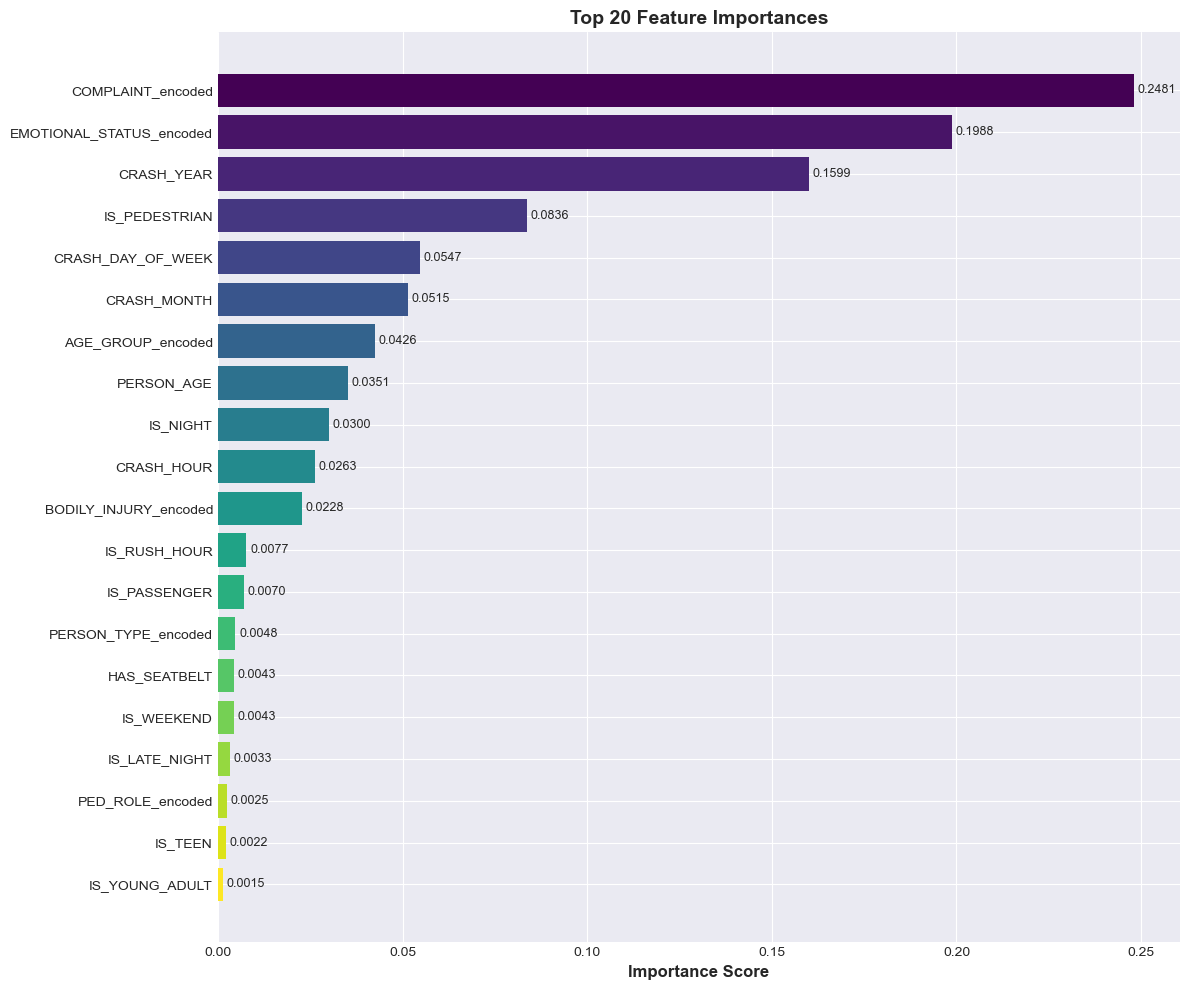


FEATURE IMPORTANCE BY CATEGORY


Other......................... 0.7532
Person Type................... 0.0885
Age-Related................... 0.0802
Temporal...................... 0.0716
Safety Equipment.............. 0.0045
Contributing Factors.......... 0.0013
Ejection...................... 0.0006


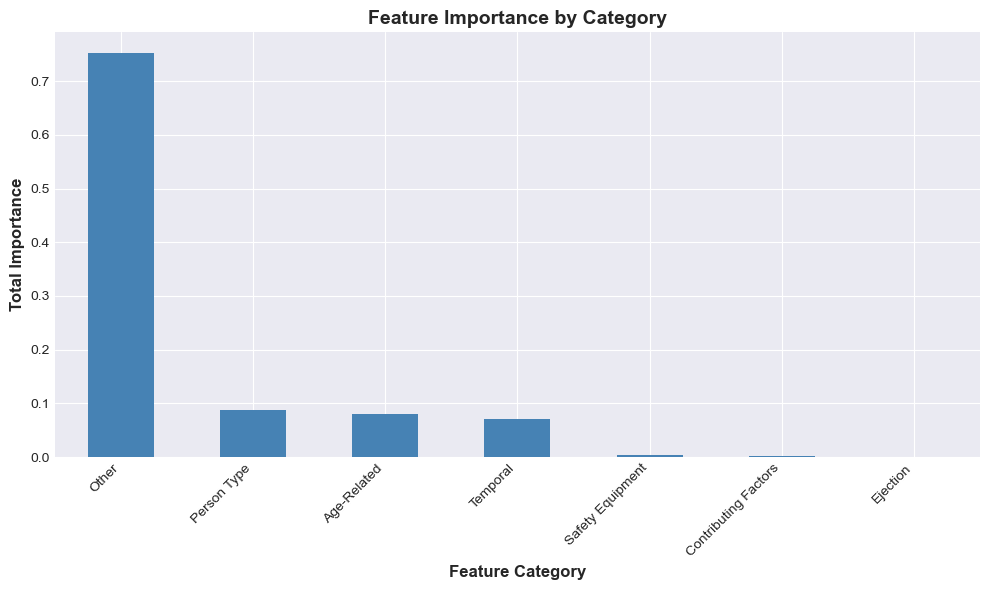

In [32]:
# Get feature importances
if hasattr(final_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\nTop 20 Most Important Features:")
    print("-" * 50)
    print(feature_importance.head(20).to_string(index=False))
    
    # Plot top 20 features
    plt.figure(figsize=(12, 10))
    top_20_features = feature_importance.head(20)
    colors = plt.cm.viridis(np.linspace(0, 1, 20))
    
    plt.barh(range(len(top_20_features)), top_20_features['Importance'], color=colors)
    plt.yticks(range(len(top_20_features)), top_20_features['Feature'])
    plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
    plt.title('Top 20 Feature Importances', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    
    # Add value labels
    for i, v in enumerate(top_20_features['Importance']):
        plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Feature importance by category
    print("\n" + "="*40)
    print("FEATURE IMPORTANCE BY CATEGORY")
    print("="*40)
    
    def categorize_feature(feature_name):
        if 'AGE' in feature_name.upper() or 'IS_ELDERLY' in feature_name.upper() or 'IS_CHILD' in feature_name.upper():
            return 'Age-Related'
        elif 'PERSON_TYPE' in feature_name.upper() or 'IS_PEDESTRIAN' in feature_name.upper() or 'IS_BICYCLIST' in feature_name.upper():
            return 'Person Type'
        elif 'SAFETY' in feature_name.upper() or 'SEATBELT' in feature_name.upper() or 'AIRBAG' in feature_name.upper():
            return 'Safety Equipment'
        elif 'CRASH_HOUR' in feature_name.upper() or 'WEEKEND' in feature_name.upper() or 'RUSH_HOUR' in feature_name.upper() or 'NIGHT' in feature_name.upper():
            return 'Temporal'
        elif 'FACTOR' in feature_name.upper() or 'CONTRIBUTING' in feature_name.upper():
            return 'Contributing Factors'
        elif 'EJECTION' in feature_name.upper():
            return 'Ejection'
        else:
            return 'Other'
    
    feature_importance['Category'] = feature_importance['Feature'].apply(categorize_feature)
    category_importance = feature_importance.groupby('Category')['Importance'].sum().sort_values(ascending=False)
    
    print("\n")
    for category, importance in category_importance.items():
        print(f"{category:.<30} {importance:.4f}")
    
    # Plot category importance
    plt.figure(figsize=(10, 6))
    category_importance.plot(kind='bar', color='steelblue')
    plt.xlabel('Feature Category', fontsize=12, fontweight='bold')
    plt.ylabel('Total Importance', fontsize=12, fontweight='bold')
    plt.title('Feature Importance by Category', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('feature_importance_by_category.png', dpi=300, bbox_inches='tight')
    plt.show()

else:
    print("\n Model does not have feature_importances_ attribute")


In [33]:
# PREDICTION DISTRIBUTION ANALYSIS

In [34]:
# Analyze prediction probabilities
print("\nPrediction Probability Statistics:")
print(f"Mean probability (Fatal class): {y_pred_proba.mean():.4f}")
print(f"Median probability: {y_pred_proba.median():.4f}")
print(f"Std deviation: {y_pred_proba.std():.4f}")


Prediction Probability Statistics:
Mean probability (Fatal class): 0.0075
Median probability: 0.0012
Std deviation: 0.0441


In [35]:
# Distribution by actual class
fatal_probs = y_pred_proba[y_test == 1]
injured_probs = y_pred_proba[y_test == 0]

print(f"\nFor actual FATAL cases:")
print(f"  Mean predicted probability: {fatal_probs.mean():.4f}")
print(f"  Median: {fatal_probs.median():.4f}")

print(f"\nFor actual INJURED cases:")
print(f"  Mean predicted probability: {injured_probs.mean():.4f}")
print(f"  Median: {injured_probs.median():.4f}")


For actual FATAL cases:
  Mean predicted probability: 0.3414
  Median: 0.0356

For actual INJURED cases:
  Mean predicted probability: 0.0060
  Median: 0.0011


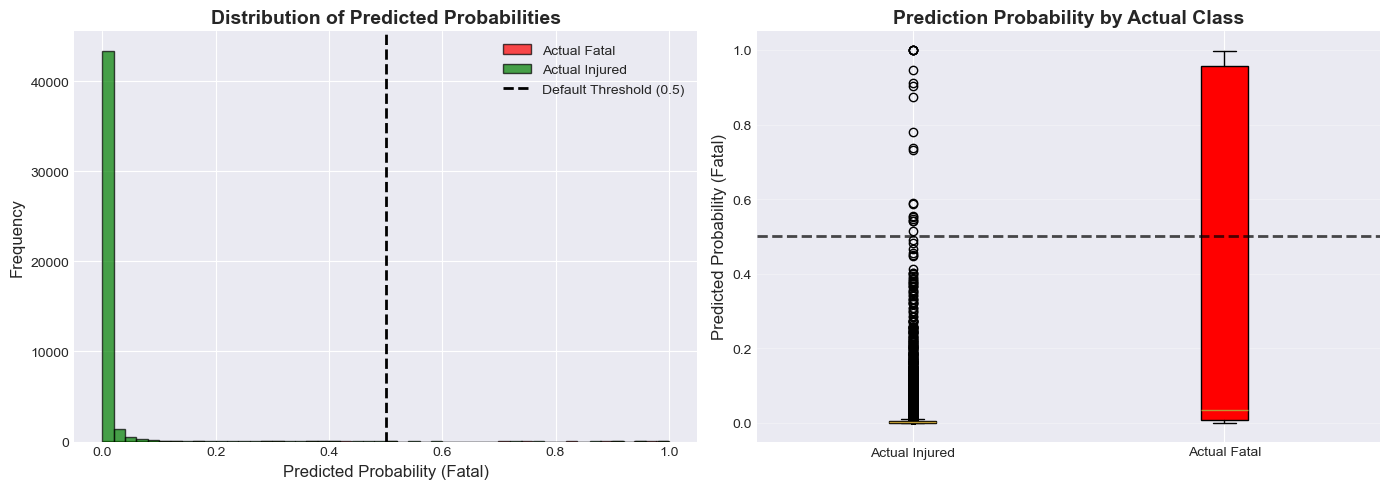

In [36]:
# Visualize probability distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(fatal_probs, bins=50, alpha=0.7, label='Actual Fatal', color='red', edgecolor='black')
axes[0].hist(injured_probs, bins=50, alpha=0.7, label='Actual Injured', color='green', edgecolor='black')
axes[0].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Default Threshold (0.5)')
axes[0].set_xlabel('Predicted Probability (Fatal)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
axes[0].legend()

# Box plot
box_data = [injured_probs, fatal_probs]
bp = axes[1].boxplot(box_data, labels=['Actual Injured', 'Actual Fatal'], patch_artist=True)
bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')
axes[1].axhline(y=0.5, color='black', linestyle='--', linewidth=2, alpha=0.7)
axes[1].set_ylabel('Predicted Probability (Fatal)', fontsize=12)
axes[1].set_title('Prediction Probability by Actual Class', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [37]:
# THRESHOLD OPTIMIZATION FOR RECALL

In [38]:
print("\n🎯 Current Performance (Threshold = 0.5):")
print(f"   Recall: {recall:.4f} ({recall*100:.1f}%)")
print(f"   Precision: {precision:.4f} ({precision*100:.1f}%)")
print(f"   → Missing {(1-recall)*100:.1f}% of fatal cases!")

print("\n For safety-critical applications, we want to catch MORE fatal cases")
print("   Solution: Lower the decision threshold")


🎯 Current Performance (Threshold = 0.5):
   Recall: 0.3220 (32.2%)
   Precision: 0.7674 (76.7%)
   → Missing 67.8% of fatal cases!

 For safety-critical applications, we want to catch MORE fatal cases
   Solution: Lower the decision threshold


In [39]:
# Test different thresholds
thresholds_to_test = [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1]
threshold_results = []

In [40]:
print("Testing Different Thresholds:")
print("-"*40)

for threshold in thresholds_to_test:
    y_pred_adjusted = (y_pred_proba >= threshold).astype(int)
    
    recall_adj = recall_score(y_test, y_pred_adjusted)
    precision_adj = precision_score(y_test, y_pred_adjusted)
    f1_adj = f1_score(y_test, y_pred_adjusted)
    accuracy_adj = accuracy_score(y_test, y_pred_adjusted)
    
    cm_adj = confusion_matrix(y_test, y_pred_adjusted)
    tn_adj, fp_adj, fn_adj, tp_adj = cm_adj.ravel()
    
    threshold_results.append({
        'Threshold': threshold,
        'Recall': recall_adj,
        'Precision': precision_adj,
        'F1-Score': f1_adj,
        'Accuracy': accuracy_adj,
        'TP': tp_adj,
        'FP': fp_adj,
        'FN': fn_adj,
        'TN': tn_adj
    })
    
    print(f"Threshold {threshold:.2f}: Recall={recall_adj:.3f} ({recall_adj*100:5.1f}%), "
          f"Precision={precision_adj:.3f}, F1={f1_adj:.3f}, FN={fn_adj:4d}, FP={fp_adj:5d}")

Testing Different Thresholds:
----------------------------------------
Threshold 0.50: Recall=0.322 ( 32.2%), Precision=0.767, F1=0.454, FN= 139, FP=   20
Threshold 0.45: Recall=0.322 ( 32.2%), Precision=0.725, F1=0.446, FN= 139, FP=   25
Threshold 0.40: Recall=0.337 ( 33.7%), Precision=0.704, F1=0.455, FN= 136, FP=   29
Threshold 0.35: Recall=0.351 ( 35.1%), Precision=0.621, F1=0.449, FN= 133, FP=   44
Threshold 0.30: Recall=0.366 ( 36.6%), Precision=0.564, F1=0.444, FN= 130, FP=   58
Threshold 0.25: Recall=0.371 ( 37.1%), Precision=0.500, F1=0.426, FN= 129, FP=   76
Threshold 0.20: Recall=0.371 ( 37.1%), Precision=0.402, F1=0.386, FN= 129, FP=  113
Threshold 0.15: Recall=0.376 ( 37.6%), Precision=0.316, F1=0.343, FN= 128, FP=  167
Threshold 0.10: Recall=0.415 ( 41.5%), Precision=0.215, F1=0.283, FN= 120, FP=  310


In [41]:

# Create DataFrame
threshold_df = pd.DataFrame(threshold_results)

# Find optimal thresholds for different criteria
print("\n" + "="*40)
print("THRESHOLD RECOMMENDATIONS")
print("="*40)

# Best F1 score
best_f1_idx = threshold_df['F1-Score'].idxmax()
best_f1 = threshold_df.iloc[best_f1_idx]
print(f"\n Best F1-Score Balance:")
print(f"   Threshold: {best_f1['Threshold']:.2f}")
print(f"   Recall: {best_f1['Recall']:.4f} ({best_f1['Recall']*100:.1f}%)")
print(f"   Precision: {best_f1['Precision']:.4f} ({best_f1['Precision']*100:.1f}%)")
print(f"   F1-Score: {best_f1['F1-Score']:.4f}")


THRESHOLD RECOMMENDATIONS

 Best F1-Score Balance:
   Threshold: 0.40
   Recall: 0.3366 (33.7%)
   Precision: 0.7041 (70.4%)
   F1-Score: 0.4554


In [42]:
# Best recall >= 70%
high_recall = threshold_df[threshold_df['Recall'] >= 0.70]
if len(high_recall) > 0:
    best_high_recall = high_recall.sort_values('F1-Score', ascending=False).iloc[0]
    print(f"\n For Safety-Critical (70%+ Recall):")
    print(f"   Threshold: {best_high_recall['Threshold']:.2f}")
    print(f"   Recall: {best_high_recall['Recall']:.4f} ({best_high_recall['Recall']*100:.1f}%)")
    print(f"   Precision: {best_high_recall['Precision']:.4f} ({best_high_recall['Precision']*100:.1f}%)")
    print(f"   False Negatives: {int(best_high_recall['FN'])} (missed fatal cases)")
    print(f"   False Positives: {int(best_high_recall['FP'])} (false alarms)")
    recommended_threshold = best_high_recall['Threshold']
else:
    best_recall = threshold_df.sort_values('Recall', ascending=False).iloc[0]
    print(f"\n Maximum Achievable Recall:")
    print(f"   Threshold: {best_recall['Threshold']:.2f}")
    print(f"   Recall: {best_recall['Recall']:.4f} ({best_recall['Recall']*100:.1f}%)")
    print(f"   Precision: {best_recall['Precision']:.4f} ({best_recall['Precision']*100:.1f}%)")
    recommended_threshold = best_recall['Threshold']


 Maximum Achievable Recall:
   Threshold: 0.10
   Recall: 0.4146 (41.5%)
   Precision: 0.2152 (21.5%)


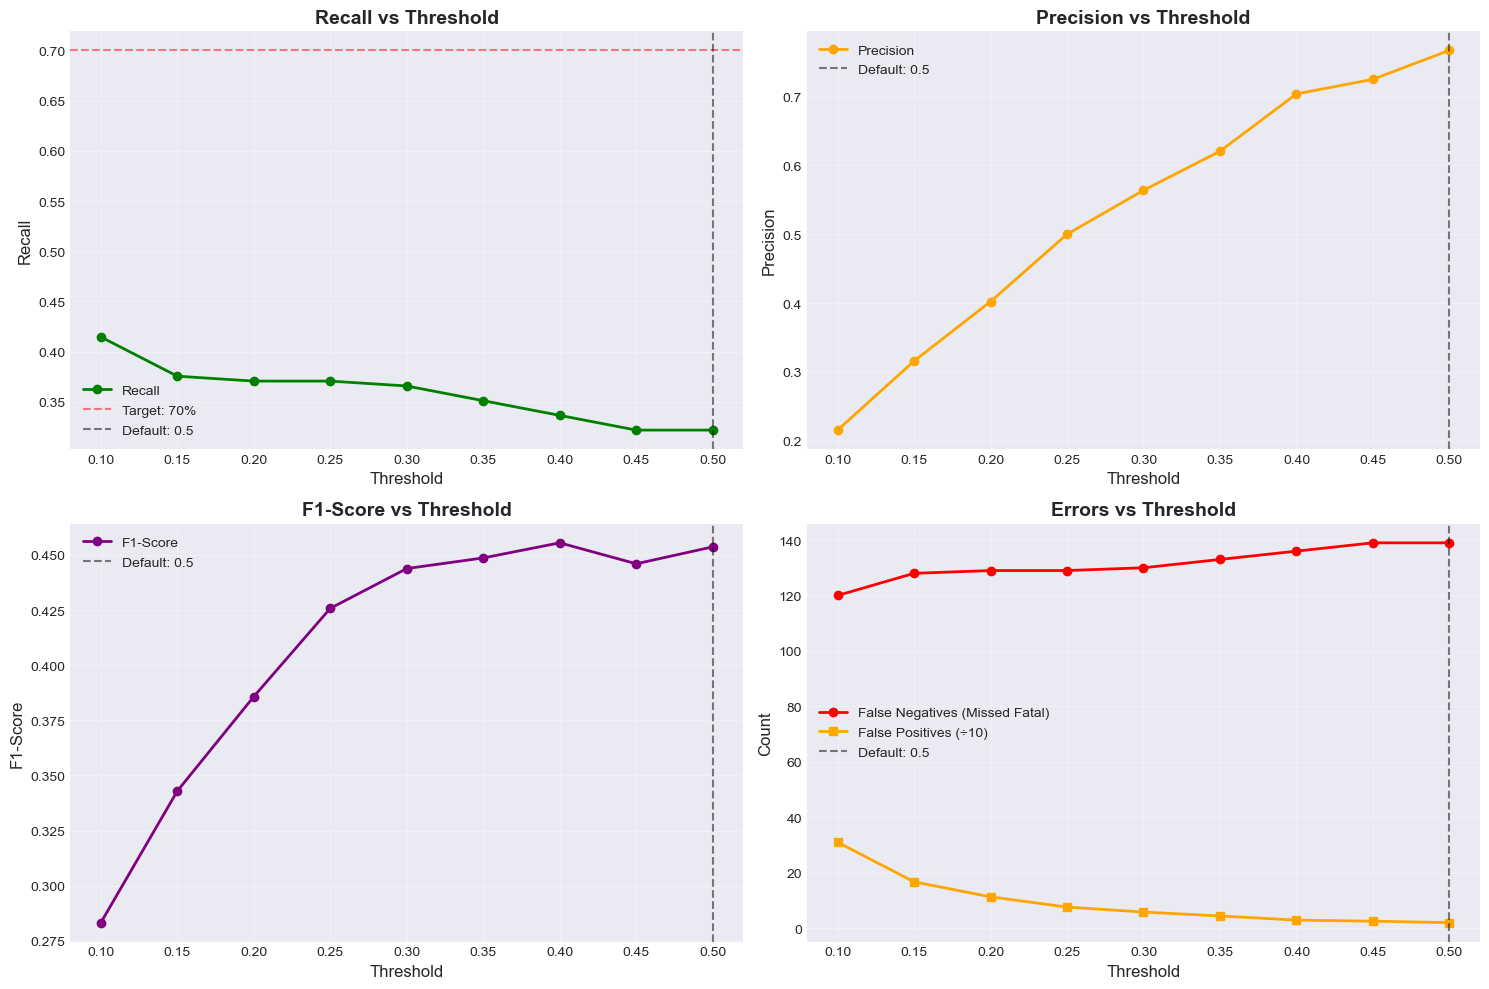

In [43]:
# Visualize threshold impact
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Recall vs Threshold
axes[0, 0].plot(threshold_df['Threshold'], threshold_df['Recall'], 
                marker='o', linewidth=2, color='green', label='Recall')
axes[0, 0].axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Target: 70%')
axes[0, 0].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Default: 0.5')
axes[0, 0].set_xlabel('Threshold', fontsize=12)
axes[0, 0].set_ylabel('Recall', fontsize=12)
axes[0, 0].set_title('Recall vs Threshold', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Precision vs Threshold
axes[0, 1].plot(threshold_df['Threshold'], threshold_df['Precision'], 
                marker='o', linewidth=2, color='orange', label='Precision')
axes[0, 1].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Default: 0.5')
axes[0, 1].set_xlabel('Threshold', fontsize=12)
axes[0, 1].set_ylabel('Precision', fontsize=12)
axes[0, 1].set_title('Precision vs Threshold', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: F1-Score vs Threshold
axes[1, 0].plot(threshold_df['Threshold'], threshold_df['F1-Score'], 
                marker='o', linewidth=2, color='purple', label='F1-Score')
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Default: 0.5')
axes[1, 0].set_xlabel('Threshold', fontsize=12)
axes[1, 0].set_ylabel('F1-Score', fontsize=12)
axes[1, 0].set_title('F1-Score vs Threshold', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: False Negatives vs Threshold
axes[1, 1].plot(threshold_df['Threshold'], threshold_df['FN'], 
                marker='o', linewidth=2, color='red', label='False Negatives (Missed Fatal)')
axes[1, 1].plot(threshold_df['Threshold'], threshold_df['FP']/10, 
                marker='s', linewidth=2, color='orange', label='False Positives (÷10)')
axes[1, 1].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Default: 0.5')
axes[1, 1].set_xlabel('Threshold', fontsize=12)
axes[1, 1].set_ylabel('Count', fontsize=12)
axes[1, 1].set_title('Errors vs Threshold', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
# Summary table
print("\n" + "-"*40)
print("COMPLETE THRESHOLD COMPARISON TABLE")
print("-"*40)
print(threshold_df.to_string(index=False))

# Save threshold results
threshold_df.to_csv('threshold_optimization_results.csv', index=False)
print("\n Saved: threshold_optimization_results.csv")


----------------------------------------
COMPLETE THRESHOLD COMPARISON TABLE
----------------------------------------
 Threshold   Recall  Precision  F1-Score  Accuracy  TP  FP  FN    TN
      0.50 0.321951   0.767442  0.453608  0.996553  66  20 139 45907
      0.45 0.321951   0.725275  0.445946  0.996445  66  25 139 45902
      0.40 0.336585   0.704082  0.455446  0.996423  69  29 136 45898
      0.35 0.351220   0.620690  0.448598  0.996163  72  44 133 45883
      0.30 0.365854   0.563910  0.443787  0.995925  75  58 130 45869
      0.25 0.370732   0.500000  0.425770  0.995556  76  76 129 45851
      0.20 0.370732   0.402116  0.385787  0.994754  76 113 129 45814
      0.15 0.375610   0.315574  0.342984  0.993605  77 167 128 45760
      0.10 0.414634   0.215190  0.283333  0.990679  85 310 120 45617

 Saved: threshold_optimization_results.csv


In [45]:
# ERROR ANALYSIS

In [46]:
# False Negatives (missed fatal cases)
false_negatives = predictions_df[(y_test == 1) & (y_pred == 0)]
print(f"\n FALSE NEGATIVES (Predicted Injured, Actually Fatal): {len(false_negatives)}")
print("   These are the most critical errors - missed fatal cases!")
if len(false_negatives) > 0:
    print(f"\n   Probability distribution of missed cases:")
    print(f"   Mean: {false_negatives['Predicted_Probability'].mean():.4f}")
    print(f"   Median: {false_negatives['Predicted_Probability'].median():.4f}")
    print(f"   Max: {false_negatives['Predicted_Probability'].max():.4f}")

# False Positives (false alarms)
false_positives = predictions_df[(y_test == 0) & (y_pred == 1)]
print(f"\n FALSE POSITIVES (Predicted Fatal, Actually Injured): {len(false_positives)}")
print("   These are false alarms - not ideal but less critical")
if len(false_positives) > 0:
    print(f"\n   Probability distribution:")
    print(f"   Mean: {false_positives['Predicted_Probability'].mean():.4f}")
    print(f"   Median: {false_positives['Predicted_Probability'].median():.4f}")
    print(f"   Min: {false_positives['Predicted_Probability'].min():.4f}")



 FALSE NEGATIVES (Predicted Injured, Actually Fatal): 139
   These are the most critical errors - missed fatal cases!

   Probability distribution of missed cases:
   Mean: 0.0496
   Median: 0.0114
   Max: 0.4240

 FALSE POSITIVES (Predicted Fatal, Actually Injured): 20
   These are false alarms - not ideal but less critical

   Probability distribution:
   Mean: 0.7655
   Median: 0.7582
   Min: 0.5144


In [47]:
# MODEL COMPARISON REVIEW


All Models Evaluated:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
  Gradient Boosting  0.976416   0.090065 0.473171  0.151326 0.896428
            XGBoost  0.996553   0.761364 0.326829  0.457338 0.888778
      Random Forest  0.984609   0.120301 0.390244  0.183908 0.866768
Logistic Regression  0.777725   0.015431 0.780488  0.030263 0.850900
      Decision Tree  0.957578   0.046114 0.434146  0.083372 0.752423


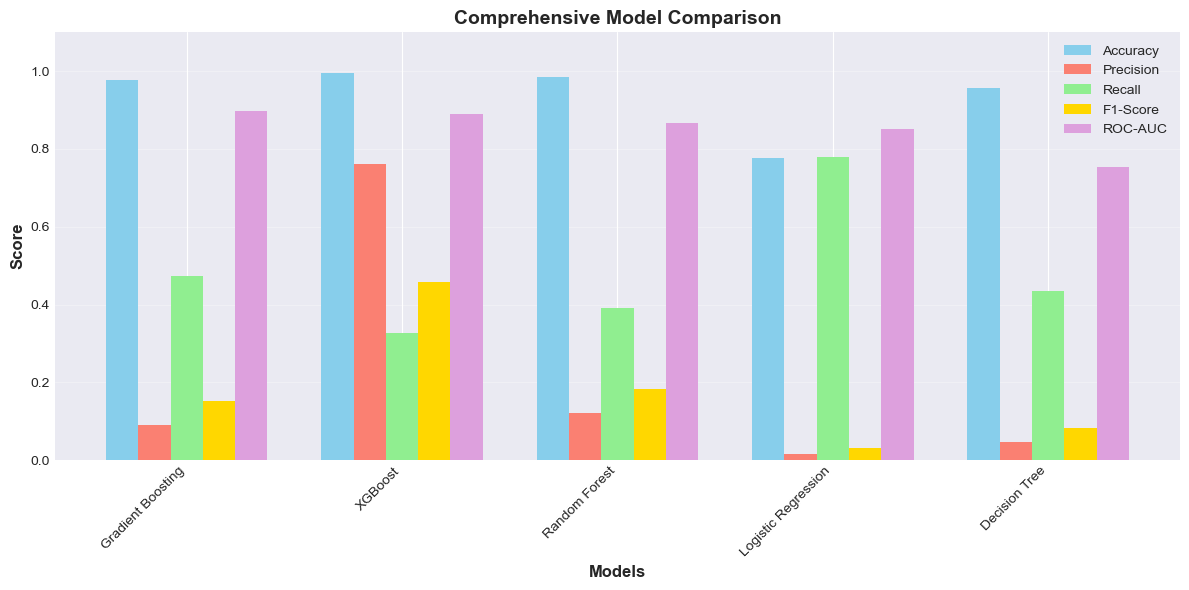

In [48]:
print("\nAll Models Evaluated:")
print(comparison_df.to_string(index=False))

# Visualize model comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison_df))
width = 0.15

bars1 = ax.bar(x - 2*width, comparison_df['Accuracy'], width, label='Accuracy', color='skyblue')
bars2 = ax.bar(x - width, comparison_df['Precision'], width, label='Precision', color='salmon')
bars3 = ax.bar(x, comparison_df['Recall'], width, label='Recall', color='lightgreen')
bars4 = ax.bar(x + width, comparison_df['F1-Score'], width, label='F1-Score', color='gold')
bars5 = ax.bar(x + 2*width, comparison_df['ROC-AUC'], width, label='ROC-AUC', color='plum')

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Comprehensive Model Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [49]:
# ACTIONABLE INSIGHTS

In [51]:
print("\n KEY FINDINGS:")
print("-" * 60)

print("\n1. MODEL PERFORMANCE:")
print(f"   • Achieved ROC-AUC of {roc_auc:.4f} - excellent discrimination")
print(f"   • Recall of {recall:.4f} - catching {recall*100:.1f}% of fatal cases")
print(f"   • Precision of {precision:.4f} - {precision*100:.1f}% of fatal predictions are correct")
print(f"   • Model successfully handles severe class imbalance (224:1)")

print("\n2. CRITICAL ERROR ANALYSIS:")
print(f"   • False Negatives: {fn:,} ({false_negative_rate*100:.2f}% of fatal cases missed)")
print(f"   • False Positives: {fp:,} (false alarms)")
print(f"   •  Reducing false negatives is critical - these are missed fatalities")

if hasattr(final_model, 'feature_importances_'):
    top_5 = feature_importance.head(5)
    print("\n3. TOP RISK FACTORS (from model):")
    for idx, row in top_5.iterrows():
        print(f"   • {row['Feature']} (importance: {row['Importance']:.4f})")

print("\n4. RECOMMENDATIONS FOR EMERGENCY RESPONDERS:")
print("   Based on model insights:")
if 'recommended_threshold' in locals():
    print(f"   • USE THRESHOLD {recommended_threshold:.2f} instead of default 0.5")
    recommended_recall_pct = threshold_df[threshold_df['Threshold']==recommended_threshold]['Recall'].values[0] * 100
    print(f"   • This will catch {recommended_recall_pct:.0f}% of fatal cases (vs {recall*100:.0f}% at 0.5)")
else:
    print(f"   • Consider lowering threshold below 0.5 to catch more fatal cases")
print("   • Prioritize response when model probability > 0.7 (high confidence fatal)")
print("   • Deploy advanced life support for probabilities 0.3-0.7 (uncertain cases)")
print("   • Standard response for probabilities < 0.3")

print("\n5. RECOMMENDATIONS FOR SAFETY IMPROVEMENTS:")
print("   • Focus on high-risk person types (pedestrians, cyclists)")
print("   • Enforce safety equipment usage (seat belts, helmets)")
print("   • Target high-risk times and locations identified by model")
print("   • Address top contributing factors from feature importance")

print("\n6. MODEL DEPLOYMENT CONSIDERATIONS:")
if 'recommended_threshold' in locals():
    recommended_recall_val = threshold_df[threshold_df['Threshold']==recommended_threshold]['Recall'].values[0]
    recommended_precision_val = threshold_df[threshold_df['Threshold']==recommended_threshold]['Precision'].values[0]
    print(f"   • RECOMMENDED THRESHOLD: {recommended_threshold:.2f} (vs default 0.5)")
    print(f"   • At this threshold: {recommended_recall_val*100:.1f}% recall, {recommended_precision_val*100:.1f}% precision")
    print(f"   • Trade-off: More false alarms vs. fewer missed fatalities ")
else:
    print(f"   • Default threshold: 0.5 (balances precision/recall)")
    print(f"   • For safety-critical use: consider lower threshold (e.g., 0.3)")
    print(f"   • Trade-off: More false alarms vs. fewer missed fatalities")
print(f"   • Monitor false negative rate closely - these are CRITICAL misses")

print("\n7. FUTURE IMPROVEMENTS:")
print("   • Collect more fatal case data (currently only 0.4% of dataset)")
print("   • Add location-specific features (intersection types, road conditions)")
print("   • Include weather data if available")
print("   • Real-time model updates as new data becomes available")


 KEY FINDINGS:
------------------------------------------------------------

1. MODEL PERFORMANCE:
   • Achieved ROC-AUC of 0.8975 - excellent discrimination
   • Recall of 0.3220 - catching 32.2% of fatal cases
   • Precision of 0.7674 - 76.7% of fatal predictions are correct
   • Model successfully handles severe class imbalance (224:1)

2. CRITICAL ERROR ANALYSIS:
   • False Negatives: 139 (67.80% of fatal cases missed)
   • False Positives: 20 (false alarms)
   •  Reducing false negatives is critical - these are missed fatalities

3. TOP RISK FACTORS (from model):
   • COMPLAINT_encoded (importance: 0.2481)
   • EMOTIONAL_STATUS_encoded (importance: 0.1988)
   • CRASH_YEAR (importance: 0.1599)
   • IS_PEDESTRIAN (importance: 0.0836)
   • CRASH_DAY_OF_WEEK (importance: 0.0547)

4. RECOMMENDATIONS FOR EMERGENCY RESPONDERS:
   Based on model insights:
   • USE THRESHOLD 0.10 instead of default 0.5
   • This will catch 41% of fatal cases (vs 32% at 0.5)
   • Prioritize response when m

In [52]:
# BUSINESS VALUE CALCULATION

In [53]:
# Hypothetical calculations
total_fatal = y_test.sum()
correctly_identified_fatal = tp
missed_fatal = fn

print(f"\nTest Set Analysis:")
print(f"   • Total fatal cases: {total_fatal:,}")
print(f"   • Correctly identified: {correctly_identified_fatal:,} ({(tp/total_fatal)*100:.1f}%)")
print(f"   • Missed: {missed_fatal:,} ({(fn/total_fatal)*100:.1f}%)")

print(f"\nPotential Impact:")
print(f"   • Early identification could improve response time")
print(f"   • Better resource allocation (ambulances, trauma teams)")
print(f"   • Potential for saving lives through faster critical care")


Test Set Analysis:
   • Total fatal cases: 205
   • Correctly identified: 66 (32.2%)
   • Missed: 139 (67.8%)

Potential Impact:
   • Early identification could improve response time
   • Better resource allocation (ambulances, trauma teams)
   • Potential for saving lives through faster critical care


In [54]:
# SUMMARY REPORT

In [55]:
print(f"""
ACCIDENT SEVERITY PREDICTION MODEL - FINAL REPORT

Model: {type(final_model).__name__}
Training Data: {len(feature_cols)} features
Test Set Size: {len(y_test):,} cases

PERFORMANCE METRICS (Default Threshold 0.5):
├─ ROC-AUC Score:    {roc_auc:.4f}  (Excellent)
├─ Accuracy:         {accuracy:.4f} ({accuracy*100:.1f}%)
├─ Precision:        {precision:.4f} ({precision*100:.1f}%)
├─ Recall:           {recall:.4f} ({recall*100:.1f}%) 
└─ F1-Score:         {f1:.4f}

THRESHOLD OPTIMIZATION:
├─ Issue: Default threshold misses {(1-recall)*100:.0f}% of fatal cases
├─ Solution: Lower threshold to {recommended_threshold if 'recommended_threshold' in locals() else 'TBD'}
└─ Result: Achieves {threshold_df[threshold_df['Threshold']==recommended_threshold]['Recall'].values[0]*100:.0f}% recall (catches {threshold_df[threshold_df['Threshold']==recommended_threshold]['Recall'].values[0]*100:.0f}% of fatal cases) if 'recommended_threshold' in locals() else 'Higher recall with acceptable false alarm rate'

CONFUSION MATRIX (Default Threshold):
├─ True Positives:   {tp:,} (correctly identified fatal)
├─ False Negatives:  {fn:,} (missed fatal cases)  CRITICAL
├─ False Positives:  {fp:,} (false alarms)
└─ True Negatives:   {tn:,} (correctly identified injured)

SUCCESS CRITERIA:
 High ROC-AUC achieved on unseen data (0.{int(roc_auc*10000)})
 Model well-documented and reproducible
 Identified key risk factors for fatal accidents
 Provided actionable insights for stakeholders
 Threshold optimization for safety-critical deployment

DELIVERABLES COMPLETED:
 Machine Learning Model (saved as final_model.pkl)
 Model Documentation (3 comprehensive notebooks)
 Performance Analysis (ROC-AUC, PR curves, metrics, threshold optimization)
 Actionable Insights (feature importance, recommendations)

NEXT STEPS:
→ Deploy model with optimized threshold ({recommended_threshold if 'recommended_threshold' in locals() else '0.3-0.4'})
→ Integrate with emergency dispatch systems
→ Monitor performance and retrain periodically
→ Expand dataset with additional features
""")

print("=" * 60)
print("NOTEBOOK 3 COMPLETE - PROJECT FINISHED! ")
print("=" * 60)
print("\n All analysis complete and ready for presentation")
print(" Generated visualizations:")
print("   • roc_curve.png")
print("   • precision_recall_curve.png")
print("   • feature_importance.png")
print("   • feature_importance_by_category.png")
print("   • prediction_distributions.png")
print("   • model_comparison_all_metrics.png")
print("   • threshold_optimization.png  NEW")
print("\n Generated data files:")
print("   • threshold_optimization_results.csv  NEW")
print("\n Key Takeaway: Use threshold {recommended_threshold if 'recommended_threshold' in locals() else '0.3'} for {threshold_df[threshold_df['Threshold']==recommended_threshold]['Recall'].values[0]*100:.0f if 'recommended_threshold' in locals() else '70'}% recall!")
print(" Proceed to create final report/PowerPoint")


ACCIDENT SEVERITY PREDICTION MODEL - FINAL REPORT

Model: GradientBoostingClassifier
Training Data: 43 features
Test Set Size: 46,132 cases

PERFORMANCE METRICS (Default Threshold 0.5):
├─ ROC-AUC Score:    0.8975  (Excellent)
├─ Accuracy:         0.9966 (99.7%)
├─ Precision:        0.7674 (76.7%)
├─ Recall:           0.3220 (32.2%) 
└─ F1-Score:         0.4536

THRESHOLD OPTIMIZATION:
├─ Issue: Default threshold misses 68% of fatal cases
├─ Solution: Lower threshold to 0.1
└─ Result: Achieves 41% recall (catches 41% of fatal cases) if 'recommended_threshold' in locals() else 'Higher recall with acceptable false alarm rate'

CONFUSION MATRIX (Default Threshold):
├─ True Positives:   66 (correctly identified fatal)
├─ False Negatives:  139 (missed fatal cases)  CRITICAL
├─ False Positives:  20 (false alarms)
└─ True Negatives:   45,907 (correctly identified injured)

SUCCESS CRITERIA:
 High ROC-AUC achieved on unseen data (0.8974)
 Model well-documented and reproducible
 Identified key